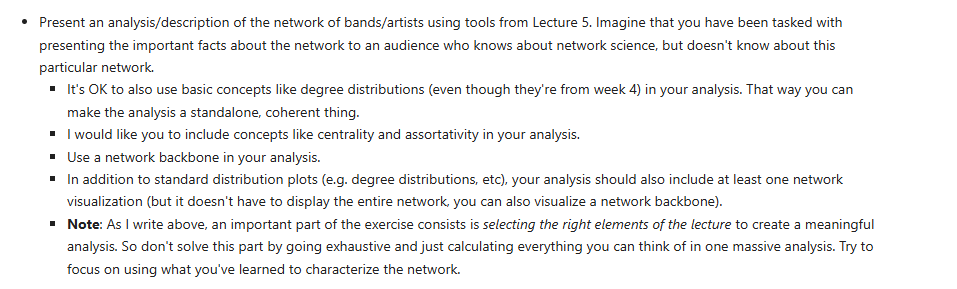

In [ ]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np
import scipy
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import urllib

In [247]:
DG.clear() 
github_base_url = "https://raw.githubusercontent.com/Somon8/social_graphs_25/main/"

def from_github(path):
    url_to_file = github_base_url + path
    return urllib.request.urlopen(url_to_file)

DG = nx.read_gexf(from_github("graphs/rock_bands_graph.gexf"))
G = DG.to_undirected()


### Stucture of the analysis
- **Context**
    1. What is the network about
    2. What are the nodes/links and content is also extracted
    3. Giant connected component
        - How many characters are removed?
        -Self-loops removed
    3. What do the links represent (singing together etc.)
- **What can we say about the degrees?**
    1. Basic stats of in and out(mean, mode, min, max)
    2. Compare in- and out-degrees. Correlation and maybe heatmap?
    2. Degree distributions compared to powerlaw, log-normal and exponential distributions. Plot it with all 3 plot-types on top.
        - Can we say anything about what these degree distributions mean?
    3. Alpha-values of powerlaw compared to different regimens
- **What can we say about the centrality of the network**
    1. What are the most connected nodes compared to the 3 centrality types?
        - What is the correlation between the centralities in this network and what can we deduce from that?
            - Should this be plotted?
    2. Is the graph assortative with regards to degree centrality? Why would it be assortative? What is the connection between assortivity and alpha-values?
    3. Important to mention the assortativity in regards to it being a proxy of a network, not the actual network. A link is not a real connection between characters, it's a connection between wiki-pages of characters.
    4. Is the graph assortative with regards to content length (MAYBE? WHERE SHOULD WE TALK ABOUT CONTENT. it's not about the content. It's just about some feature)
    5. How closely does it compare to a random network on shortest path
- **What can we say about the backbone of the network?**
- **Some overall conclusion?**

# Introduction to the Rock Performers Network
The Rock Performers network is a network based on the "List of Mainstream Rock Performers" page on wikipedia (https://en.wikipedia.org/wiki/List_of_mainstream_rock_performers). It is a network based on the interactions between Performers, where links indicate their interactions.  

Specifically, the Rock Performers network consists of nodes of performers, and directed links where the wikipedia page of Performer A references the page of Performer B. Upon qualitative inspection of the wikipedia pages, we conclude that the references are usually when performers have been inspired by other performers, if they have played together or if a person has changed from one band to another.  

The Performers network is realistically more a proxy for the actual network of rock performers, as their interactions in real life do not neccesarily have that much to do with the references on their wikipedia page.  

The "List of Mainstream Rock Performers" consists of 488 pages. After scraping the data and extracting the giant connected component, the directed network we create from it consists of 461 nodes. The reason it contains less nodes is partly that some pages are redirects or have peculiar wikipedia pages. For the sake of analyzing the network, we disregard these 27 pages. Additionally we remove self-loops in the network.  (SHOULD I ADD A REASON WHY?)  

## Basic Degree Descriptions
The In-degree of the network varies much more than the out-degrees. It has a higher standard deviation, and the size of the 4th quartile for the in-degrees is significantly bigger than that of the out-degrees. Additionallly the in-degree has a mode of 3 with 37 observations, where the out-degree has a mode of 12 with 27 observations.  

Interpreting the statistics tells us that the amount of other performers that a page mentions, is much more "balanced" than the amount of times that page itself is mentioned. In other words, some performers are significantly more mentioned than others. This aligns with a "winner takes it all" development where nodes being mentioned is a reinforcing mechanism, and those nodes that are most mentioned are more likely to be mentioned when a neew wikipedia page for a performer is added.  

To understand whether or not the network degrees follows a power-law, we plot 4 different distributions on top of the degree distributions and evaluate them using the Kolgomorov-Smirnov statistic. The degree distributions are compared to a power-law, an exponential distribution, a log-normal distrbution and a poisson-distribution. This evaluation clearly shows that a powerlaw is not the best fit for either of the degree distributions, and that a log-normal distribution is the best fit. This indicates that xxxx
Additionally the poisson distribution has a better fit than the power-law for both of the distributions. The Network is more like a random network, which follows a poisson distribution, than a scale-free network which follows a power-law.

In [248]:
node_stats = []

for node in DG.nodes():
    in_degree = DG.in_degree(node)
    out_degree = DG.out_degree(node)
    node_stats.append((node, in_degree, out_degree))

df = pd.DataFrame(node_stats, columns = ["Node", "In Degree", "Out Degree"])
df.set_index("Node", inplace = True)

print(df.describe().to_string(float_format="{:.3f}".format))

print("The mode of in-degrees are {} with {} observations".format(scipy.stats.mode(df['In Degree'])[0], scipy.stats.mode(df['In Degree'])[1]))
print("The mode of out-degrees are {} with {} observations".format(scipy.stats.mode(df['Out Degree'])[0], scipy.stats.mode(df['Out Degree'])[1]))

       In Degree  Out Degree
count    461.000     461.000
mean      15.642      15.642
std       16.914      10.593
min        1.000       1.000
25%        4.000       8.000
50%       10.000      14.000
75%       20.000      21.000
max      115.000      72.000
The mode of in-degrees are 3 with 37 observations
The mode of out-degrees are 12 with 27 observations


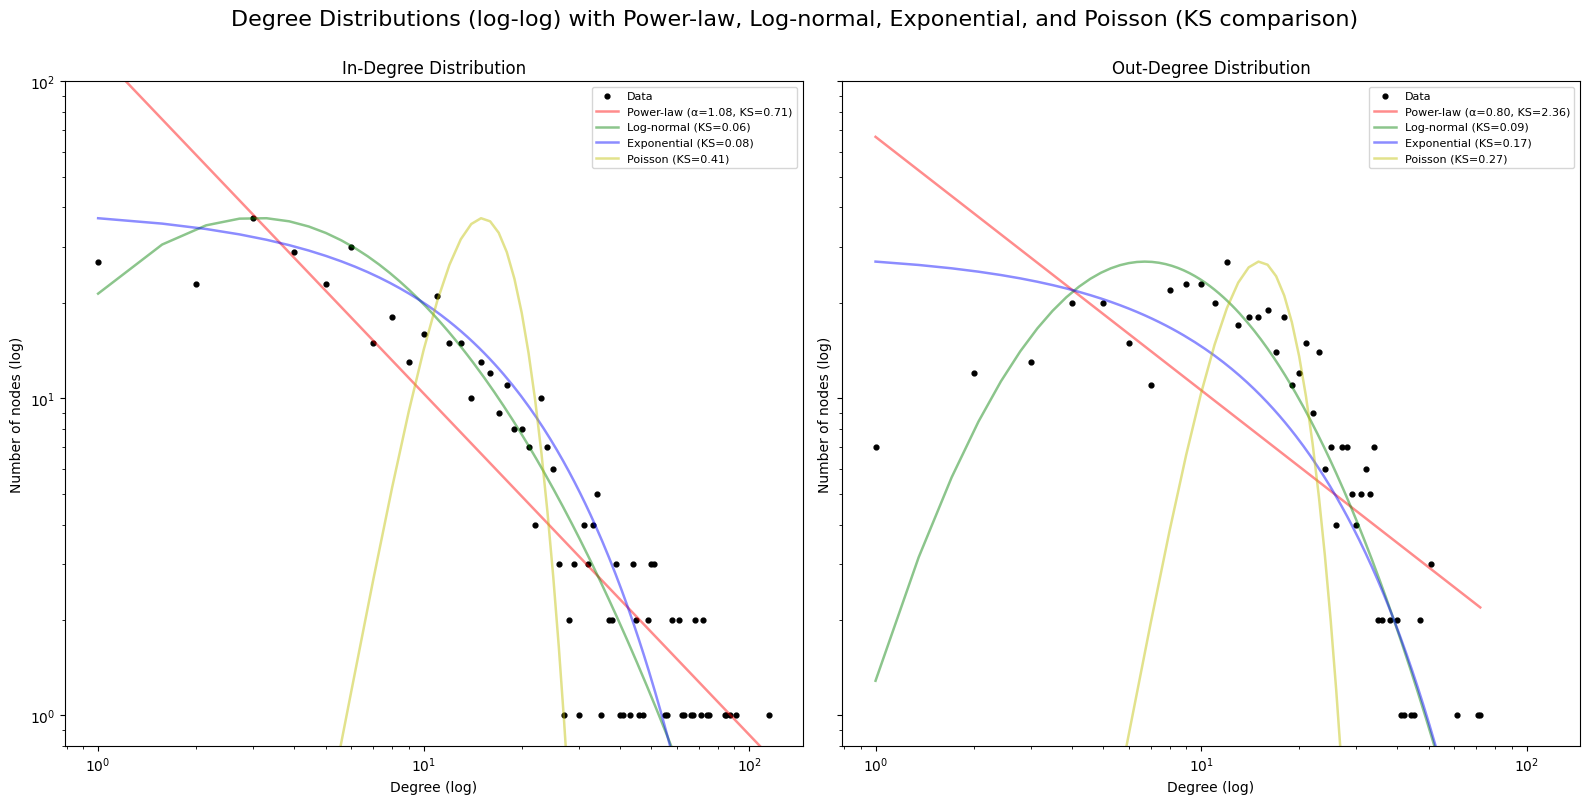

In [305]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

def fit_and_plot(series, ax, title):
    # Keep a copy with zeros (for parameter estimation), and a positive-only copy (for plotting/KS)
    data_all = np.asarray(series).astype(int)
    data = data_all[data_all > 0]        # positive degrees for log-log plotting & KS

    # --- Empirical distribution (positive) ---
    unique_degrees, counts = np.unique(data, return_counts=True)
    n = len(data)
    empirical_cdf_x = np.sort(data)
    empirical_cdf_y = np.arange(1, n + 1) / n

    # ---------- POWER-LAW ----------
    log_x = np.log(unique_degrees)
    log_y = np.log(counts)
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]
    intercept = np.exp(coeffs[1])
    powerlaw_y = intercept * unique_degrees ** (-alpha)

    # KS for power-law on positive data, xmin = min(data)
    xmin = data.min()
    sorted_data = empirical_cdf_x
    cdf_powerlaw = 1 - (xmin / sorted_data) ** (alpha - 1)
    ks_powerlaw = np.max(np.abs(empirical_cdf_y - cdf_powerlaw))

    # ---------- LOG-NORMAL (fit on positive data) ----------
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    lognorm_x = np.linspace(1, data.max(), 200)
    lognorm_pdf = stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    lognorm_y = lognorm_pdf * counts.max() / lognorm_pdf.max()
    ks_lognorm = stats.kstest(data, 'lognorm', args=(shape, loc, scale)).statistic

    # ---------- EXPONENTIAL (fit on positive data) ----------
    exp_params = stats.expon.fit(data)  # (loc, scale)
    exp_x = np.linspace(1, data.max(), 200)
    exp_pdf = stats.expon.pdf(exp_x, *exp_params)
    exp_y = exp_pdf * counts.max() / exp_pdf.max()
    ks_exp = stats.kstest(data, 'expon', args=exp_params).statistic

    # ---------- POISSON (zero-truncated KS; curve on positive support) ----------
    # Estimate λ by MLE on the *original* (including zeros) degrees
    lam = data_all.mean()
    # Zero-truncated Poisson CDF: (F(k) - P(0)) / (1 - P(0)) for k >= 1
    p0 = stats.poisson.pmf(0, mu=lam)
    cdf_po_trunc = (stats.poisson.cdf(sorted_data, mu=lam) - p0) / (1 - p0)
    ks_pois = np.max(np.abs(empirical_cdf_y - cdf_po_trunc))

    # Poisson curve (pmf scaled to counts) on k >= 1
    k_vals = np.arange(1, data.max() + 1)
    pois_pmf = stats.poisson.pmf(k_vals, mu=lam)
    pois_pmf_trunc = pois_pmf / (1 - p0)          # zero-truncated pmf (sum over k>=1 = 1)
    pois_y = pois_pmf_trunc * counts.max() / pois_pmf_trunc.max()

    line_transparency = 0.45

    # ---------- PLOT ----------
    ax.scatter(unique_degrees, counts, s=12, color='black', alpha=1, label='Data')
    ax.plot(unique_degrees, powerlaw_y, 'r', lw=1.8, alpha = line_transparency
            ,label=f'Power-law (α={alpha:.2f}, KS={ks_powerlaw:.2f})')
    ax.plot(lognorm_x, lognorm_y, 'g', lw=1.8,alpha = line_transparency
            ,label=f'Log-normal (KS={ks_lognorm:.2f})')
    ax.plot(exp_x, exp_y, 'b', lw=1.8,alpha = line_transparency
            ,label=f'Exponential (KS={ks_exp:.2f})')
    ax.plot(k_vals, pois_y, 'y', lw=1.8,alpha = line_transparency
            ,label=f'Poisson (KS={ks_pois:.2f})')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Number of nodes (log)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0.8, top = 100)

# ---- Run for in-degree and out-degree ----
fit_and_plot(df['In Degree'], axs[0], 'In-Degree Distribution')
fit_and_plot(df['Out Degree'], axs[1], 'Out-Degree Distribution')

plt.suptitle("Degree Distributions (log-log) with Power-law, Log-normal, Exponential, and Poisson (KS comparison)", y= 1, fontsize = 16)
plt.tight_layout()
plt.show()


>**Figure 1:** The plot shows the distributions of the In Degree (left) and the Out Degree (right). The distributions are shown on a log-log scale, and compared to the PDF of 4 different distributions, a Power-law Distribution, a Log-Normal Distribution, an Exponential Distribution and a Poisson Distribution. For both distributions the Log-Normal (green line) distributions has the best fit (KS = 0.06, KS = 0.09), indicating that the network is xxx (INSERT SOMETHING HERE) 

### Correlation between In- and Out-Degrees
The following is a logical train of thought: The performers which have a high in-degree are very influential and famous. Given their fame, much will be written about them by their fans. The more content that is on a page, the more links it will include, and the higher the out-degree will be.  
This results in the folllowing hyppothesis: In-degree is correlated with content-length, content-length is correlated with out-degree and by extension, in-degree could be correlated with out-degree.  
The correlation between Content Length and respectively Out-Degrees and In-Degrees are 0.62 and 0.66.

In [307]:
df['Content Length'] = nx.get_node_attributes(DG, "content_length")

#Something about correlation between content-length and how it affects degrees
cor_cont_out = df['Content Length'].corr(df['Out Degree'], method = "pearson")
cor_cont_in = df['Content Length'].corr(df['In Degree'], method = "pearson")

print(f"Correlation between Content Length and Out-Degrees: {cor_cont_out:.2f}")
print(f"Correlation between Content Length and In-Degrees: {cor_cont_in:.2f}")

Correlation between Content Length and Out-Degrees: 0.62
Correlation between Content Length and In-Degrees: 0.66


We evaluate the correlation between the In and Out-Degrees of the network using both Spearman and Pearson correlation. It has a Spearman-correlation of 0.67 and a Pearson correlation of 0.59. The distributions have a somewhat monotonic relationship, but it is more monotonic (0.67) than it is linear (0.57). There is however still a correlation. We also visually analyze this correlation with a scatterplot and a heatmap. The scatterplot shows the datapoints compared to a reference line with perfect correlation, and it becomes apparent that the observations do somewhat follow the reference line. To supp 

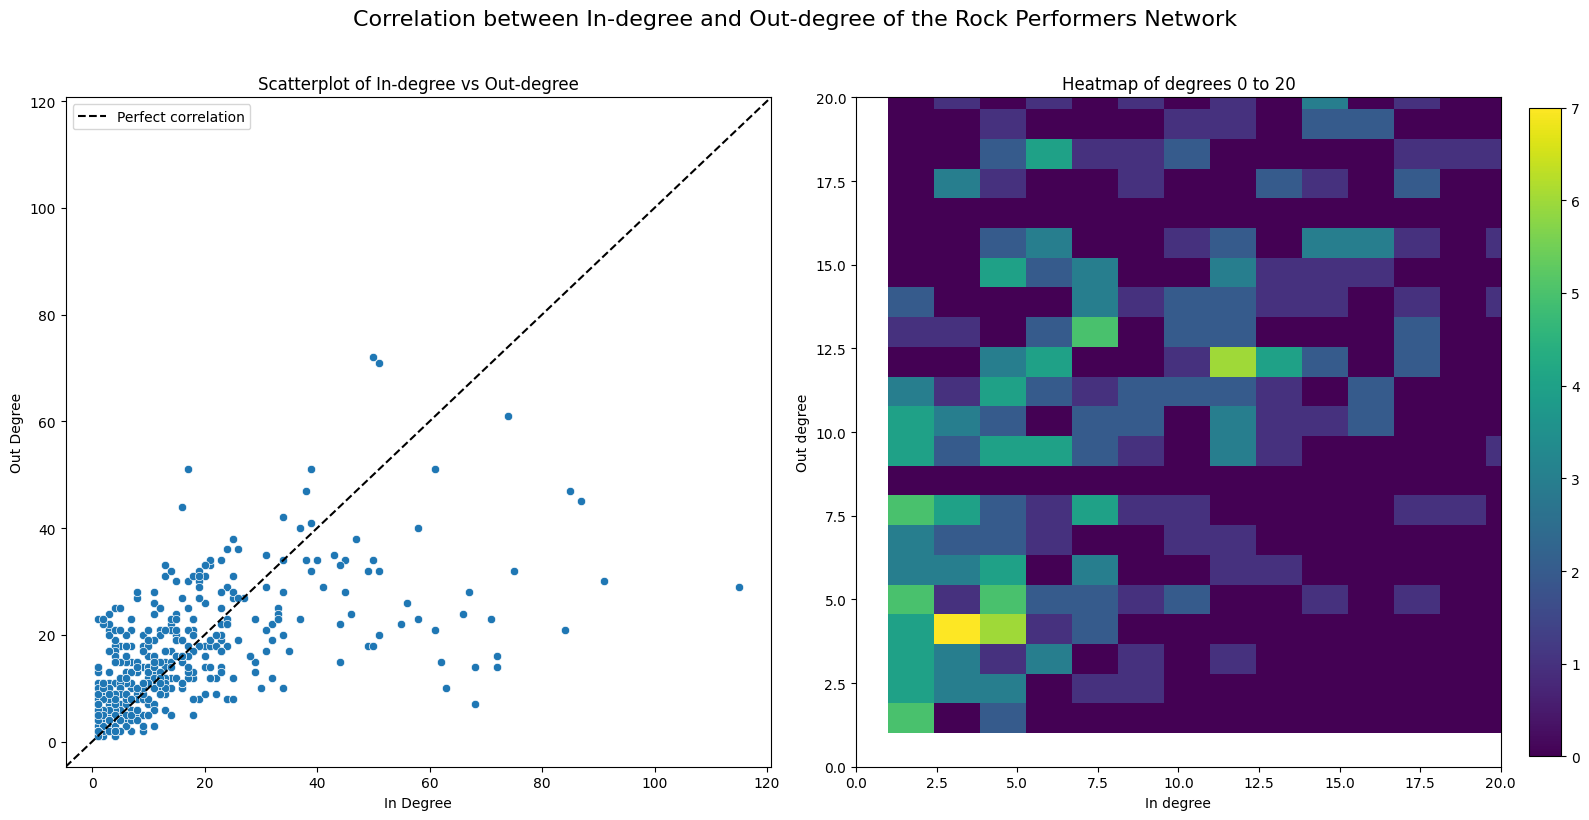

The Pearson correlation is 0.59 and the Spearman correlation is 0.67


In [ ]:
figure, axs = plt.subplots(1, 2, figsize=(16, 8))  # Row, col, w, h

# --- Scatterplot ---
sns.scatterplot(data=df, x="In Degree", y="Out Degree", ax=axs[0])

# Draw x = y line (perfect correlation reference)
lims = [
    np.min([axs[0].get_xlim(), axs[0].get_ylim()]),  # min of both axes
    np.max([axs[0].get_xlim(), axs[0].get_ylim()])   # max of both axes
]
axs[0].plot(lims, lims, color='black', linestyle='--', label='Perfect correlation')
axs[0].set_xlim(lims)
axs[0].set_ylim(lims)
axs[0].legend()
axs[0].set_title("Scatterplot of In-degree vs Out-degree")

# --- 2D Heatmap ---
heatmap_data, xedges, yedges = np.histogram2d(df["In Degree"], df["Out Degree"], bins=80)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = axs[1].imshow(heatmap_data.T, extent=extent, origin='lower', aspect='auto')
axs[1].set_xlabel("In degree")
axs[1].set_ylabel("Out degree")
axs[1].set_title("Heatmap of degrees 0 to 20")
axs[1].set_xlim(0, 20)
axs[1].set_ylim(0, 20)

# Optional colorbar
figure.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

# --- Layout and title ---
plt.suptitle("Correlation between In-degree and Out-degree of the Rock Performers Network",
             y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# --- Correlations ---
cor_pearson = df['In Degree'].corr(df['Out Degree'], method="pearson")
cor_spearman = df['In Degree'].corr(df['Out Degree'], method="spearman")
print(f"The Pearson correlation is {cor_pearson:.2f} and the Spearman correlation is {cor_spearman:.2f}")


>**Figure 2:** The plot shows

In [251]:
df['Degree Centrality'] = nx.degree_centrality(DG)
df['Betweenness Centrality'] = nx.betweenness_centrality(DG)
df['Eigenvector Centrality'] = nx.eigenvector_centrality(DG)

df['Degree Centrality'] = df['Degree Centrality'].round(5)
df['Betweenness Centrality'] = df['Betweenness Centrality'].round(5)
df['Eigenvector Centrality'] = df['Eigenvector Centrality'].round(5)

top5_summary = pd.DataFrame({
    'Degree Centrality': df['Degree Centrality'].nlargest(5),
    'Betweenness Centrality': df['Betweenness Centrality'].nlargest(5),
    'Eigenvector Centrality': df['Eigenvector Centrality'].nlargest(5)
}).fillna("Not in top 5")


print(top5_summary.to_string(float_format="{:.3f}".format))

cor_Degree_Between = df['Degree Centrality'].corr(df['Betweenness Centrality'], method = "pearson")
cor_Degree_Eigen = df['Degree Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")
cor_Between_Eigen = df['Betweenness Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")

print(f"Correlation between Degree and Betweenness Centrality: {cor_Degree_Between:.3f}")
print(f"Correlation between Degree and Eigenvector Centrality: {cor_Degree_Eigen:.3f}")
print(f"Correlation between Betweenness and Eigenvector Centrality: {cor_Between_Eigen:.3f}")

                Degree Centrality Betweenness Centrality Eigenvector Centrality
Node                                                                           
Alice in Chains      Not in top 5                  0.036           Not in top 5
Black Sabbath               0.293                  0.035                  0.200
Deep Purple                 0.265                  0.046           Not in top 5
Jimi Hendrix         Not in top 5                  0.035           Not in top 5
Kiss (band)          Not in top 5           Not in top 5                  0.162
Led Zeppelin                0.313           Not in top 5                  0.225
Metallica                   0.287           Not in top 5                  0.188
Queen (band)                0.287                  0.041                  0.183
Correlation between Degree and Betweenness Centrality: 0.875
Correlation between Degree and Eigenvector Centrality: 0.920
Correlation between Betweenness and Eigenvector Centrality: 0.775


### Assortativity

In [ ]:
df['Avg Successor In-Degree'] = nx.average_neighbor_degree(DG, source = "out", target = "in") #What is the average in-degree of the successors to the node (of the nodes that the node points to)

avg_successor_content = {}

for node in DG.nodes():
    successors = list(DG.successors(node))
    if not successors:
        avg_successor_content[node] = np.nan
    else:
        avg_successor_content[node] = df.loc[successors, 'Content Length'].mean()

df['Avg Successor Content Length'] = df.index.map(avg_successor_content)


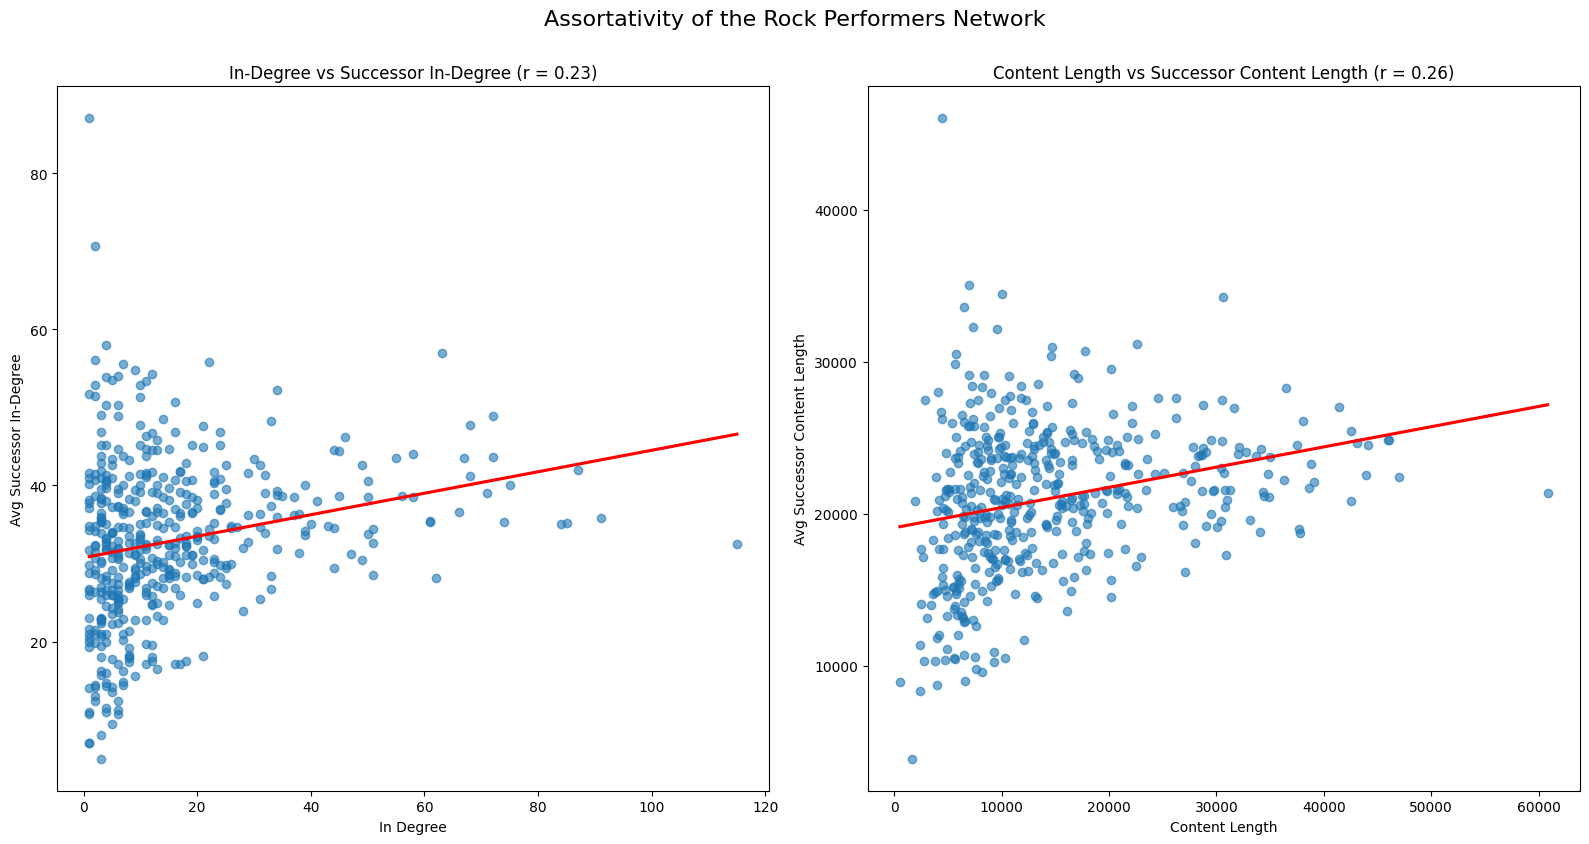

In [309]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# --- 1. In-degree vs Avg Successor In-degree. #Do the nodes with a high in-degree point to other nodes with high in-degree? No!
sns.regplot(
    data=df, x="In Degree", y="Avg Successor In-Degree", ax=axs[0]
    , scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ci=None)
r1, p1 = scipy.stats.pearsonr(df["In Degree"], df["Avg Successor In-Degree"])
axs[0].set_title(f"In-Degree vs Successor In-Degree (r = {r1:.2f})")


# --- 2. Content Length vs Avg Successor Content Length
sns.regplot(
    data=df, x="Content Length", y="Avg Successor Content Length", ax=axs[1]
    ,scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ci=None
)
r2, p2 = scipy.stats.pearsonr(df["Content Length"], df["Avg Successor Content Length"])
axs[1].set_title(f"Content Length vs Successor Content Length (r = {r2:.2f})")

plt.tight_layout()
plt.suptitle("Assortativity of the Rock Performers Network", y= 1.05, fontsize = 16)
plt.show()

>**Figure 3:** The plot shows

In [313]:
louvain_communities = nx.community.louvain_communities(DG, weight='weight', seed = 42)

louvain_communities[0]
for com_idx, community in enumerate(louvain_communities):
    for node in community:
        df.at[node, 'Louvain Community'] = int(com_idx)

df.to_csv("graphs/node_df.csv", index = True)

In [314]:
df

,In Degree,Out Degree,Degree Centrality,Betweenness Centrality,Eigenvector Centrality,Avg Neighbour In-Degree,Content Length,Avg Successor In-Degree,Avg Successor Content Length,Louvain Community
Node,,,,,,,,,,
10 Years (band),7,10,0.03696,0.00089,0.01243,21.000000,4501,21.000000,16465.700000,3.0
Disturbed (band),20,33,0.11522,0.00462,0.03755,24.939394,11700,24.939394,16873.000000,3.0
Breaking Benjamin,21,33,0.11739,0.00648,0.02216,18.151515,16494,18.151515,14934.696970,3.0
Mudvayne,7,15,0.04783,0.00038,0.01956,36.333333,7843,36.333333,23317.400000,1.0
Korn,38,34,0.15652,0.00876,0.08627,31.352941,30035,31.352941,19154.735294,3.0
...,...,...,...,...,...,...,...,...,...,...
The Jesus and Mary Chain,1,13,0.03043,0.00035,0.00310,20.461538,9465,20.461538,15614.538462,0.0
Smash Mouth,1,14,0.03261,0.00019,0.00027,28.785714,9336,28.785714,20918.857143,3.0
Smokie (band),1,2,0.00652,0.00010,0.00157,7.000000,4730,7.000000,10387.500000,4.0


In [315]:
# #Compare to random

# ######################################## IS ThIS SUPPOSED TO BE ON THE UN-DIRECTED GRAPH?
# n_nodes = len(DG.nodes)
# n_edges = len(DG.edges)

# ER = nx.erdos_renyi_graph(n = n_nodes, p =  n_edges/(n_nodes*(n_nodes-1)))

# print("The average shortest path length of the undirected rock network is:", nx.average_shortest_path_length(DG))
# print("The average shortest path length of the random network is:", nx.average_shortest_path_length(ER))

In [316]:
# Backbone calculations.
import backboning

g_df = nx.to_pandas_edgelist(DG, source = "src", target = "trg") #Construct edgelist df from graph
g_df.drop(columns = ['id'], inplace=True) #Drop the generated "id" column
g_df['nij'] = 1.0 #Set edge weight to 1

hss_df = backboning.high_salience_skeleton(g_df)

percentage_kept = 0.10 #What percentage of links are we keeping?

threshold_value = np.quantile(hss_df['score'], 1-percentage_kept) 

backbone_df = backboning.thresholding(hss_df, threshold_value)

HSS_G = nx.from_pandas_edgelist(df = backbone_df, source = "src", target= "trg", edge_attr="score"
                                , create_using=nx.DiGraph)

Calculating HSS score...


c:\Users\ThorNørgaardEriksen\OneDrive - Intellishore\3. Privat\2. Studie\2. Kurser\02805 - Social Graphs\socialgraphs\Lib\site-packages\networkx\drawing\layout.py:1809: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance
c:\Users\ThorNørgaardEriksen\OneDrive - Intellishore\3. Privat\2. Studie\2. Kurser\02805 - Social Graphs\socialgraphs\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


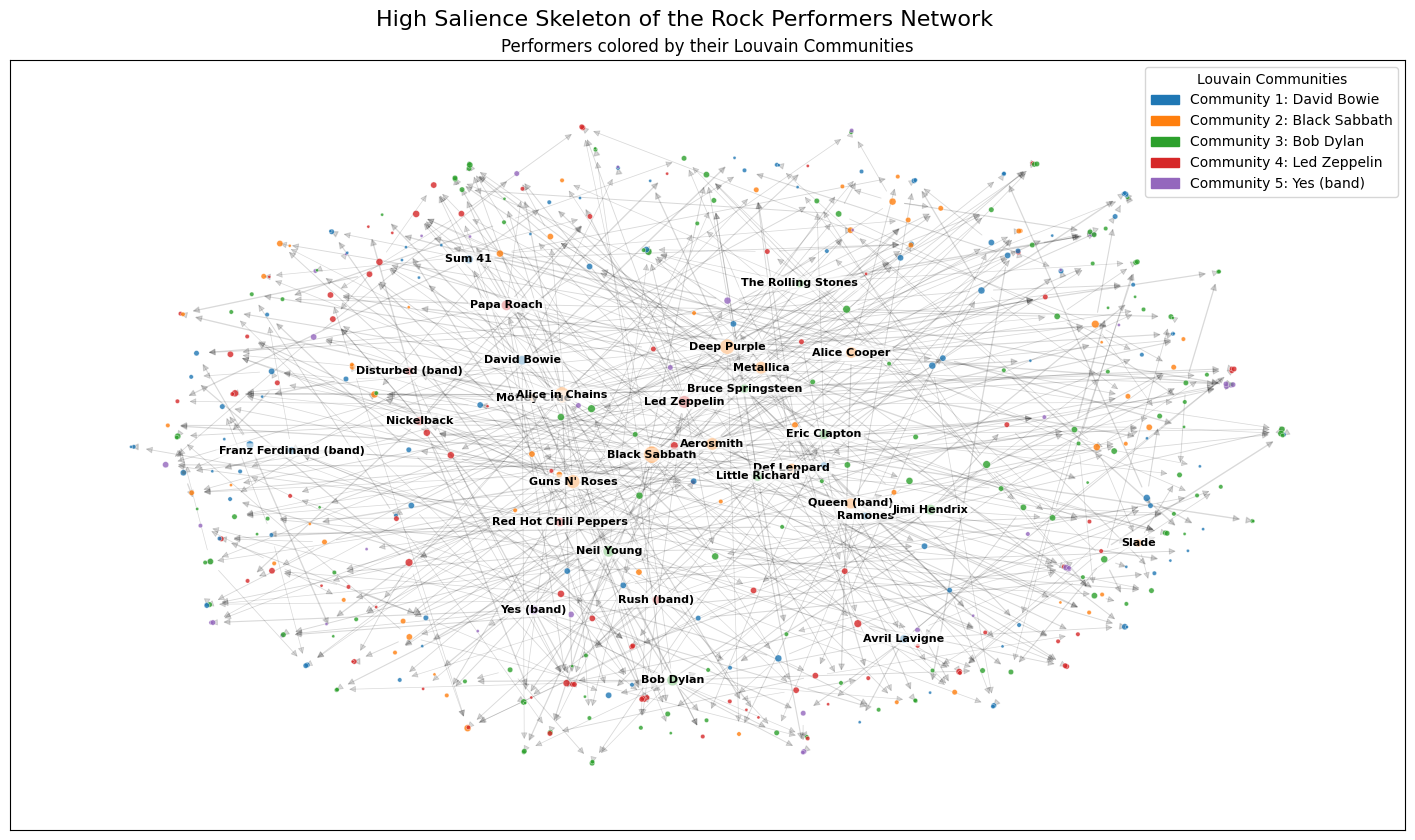

In [ ]:
HSS_G_total_degrees = {node: HSS_G.degree(node) for node in HSS_G.nodes()}
HSS_G_node_sizes = [HSS_G_total_degrees[node]*5 for node in HSS_G.nodes()] 
HSS_G_hubs = sorted(HSS_G.degree, key=lambda x: x[1], reverse=True)[:30]
HSS_G_label_nodes = {n for n,_ in HSS_G_hubs}

edge_weights = [weight for (u,v), weight in nx.get_edge_attributes(HSS_G, 'score').items()]

#Plot settings
figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height

nx.set_edge_attributes(HSS_G, 
    {edge: d.get('score', 1.0) for edge, d in HSS_G.edges.items()}, 
    'weight'
)

#Colors
colors = []
for node in HSS_G.nodes(): ########################################################     CHANGE THIS SECTION FOR PLOTTING FOR DIFFERENT COMMUNITIES
    colors.append(cm.tab10(int(df.loc[node, 'Louvain Community'])))

#Find a top node for each of the communities
top_nodes = {}
for community_id in df['Louvain Community'].unique():
    top_node = df[df['Louvain Community'] == community_id]['Degree Centrality'].idxmax(axis = 0)
    top_nodes.update({community_id: top_node})

# --- Legend for top communities (representative node = hub) ---
legend_handles = []
for com_idx, community in enumerate(louvain_communities):
    top_node = top_nodes[com_idx]
    legend_handles.append(
        mpatches.Patch(color=cm.tab10(com_idx % 10), label=f"Community {com_idx+1}: {top_node}")
    )

# --- Add legend ---
plt.legend(handles=legend_handles, title="Louvain Communities")


#################################################################################### STANDARD PLOTTING
#Get the force atlas positions
force_positions = nx.forceatlas2_layout(HSS_G
                                        ,scaling_ratio = 1
                                        ,gravity=0.1 #This is cool
                                        ,linlog = True #I LIKE THIS BUT I NEED TO EXPLAIN IT
                                        # ,distributed_action=True #EXPLAIN WHAT THIS DOES
                                        )

#Draw edges
nx.draw_networkx_edges(HSS_G, pos = force_positions, alpha = 0.15, edge_color = "k", ax=axs
                       , width=edge_weights
                       )

#Draw nodes
nx.draw_networkx_nodes(HSS_G, pos = force_positions, alpha = 0.8, edgecolors = "white", linewidths = 0.3, ax=axs
                       , node_size=HSS_G_node_sizes, node_color=colors
                       )


nx.draw_networkx_labels(
    HSS_G,
    ax=axs,
    pos=force_positions,              # or use force_positions directly
    labels={node:node if node in HSS_G_label_nodes else '' for node in HSS_G.nodes()},            # only these nodes will get text
    font_size=8,
    font_weight="bold",
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)  # improves readability
)

plt.suptitle("High Salience Skeleton of the Rock Performers Network", y= 0.93, fontsize = 16)
plt.title("Performers colored by their Louvain Communities")
plt.show()

>**Figure 4:** The plot shows